# Predicting Customer Subscription Behaviour Using Supervised Classification Techniques.


--**This section loads the Bank Marketing dataset from Google Drive and performs initial inspection of its structure and size.**

### Mount Google Drive

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Locate + unzip bank.zip

In [32]:
import zipfile, os

zip_path = "/content/drive/MyDrive/bank.zip"
extract_path = "/content/bank_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Files:", os.listdir(extract_path))

Extracted to: /content/bank_data
Files: ['bank-names.txt', 'bank-full.csv', 'bank.csv']


### 1. Load the dataset

In [33]:
import pandas as pd
import os

csv_path = os.path.join("/content/bank_data", "bank-full.csv")
df = pd.read_csv(csv_path, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Shape and info of the dataset.

In [34]:
## Dataset Overview
print(df.shape)
df.info()
df['y'].value_counts(normalize=True)

(45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,proportion
y,
no,0.883015
yes,0.116985


### 2. Separate feature types

In [35]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'poutcome', 'y'],
       dtype='object'))

### 3. Target Variable analysis.


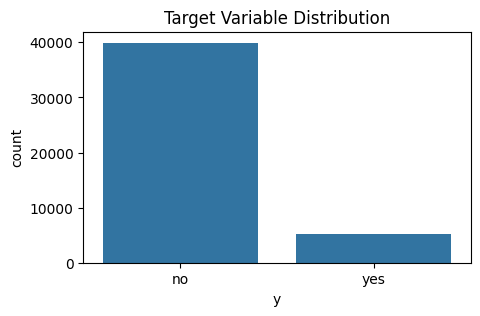

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

**The target variable is imbalanced, with approximately 11.7% positive subscription cases and 88.3% negative cases. This suggests that evaluation should focus on metrics such as precision, recall, F1-score, and ROC-AUC rather than accuracy alone.**

### The dataset exhibits class imbalance, with significantly fewer positive subscription cases.

### 4. Univariate EDA – Numerical Features

In [37]:
df[num_cols].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Numerical variables were analysed to understand their distributions, detect skewness, and identify possible outliers.**

### Distribution plots

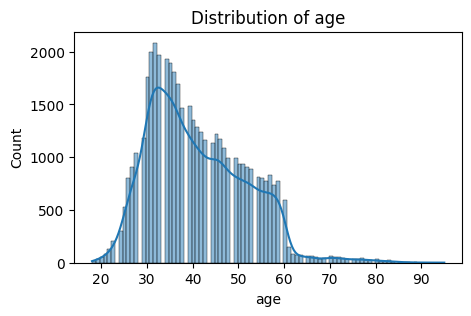

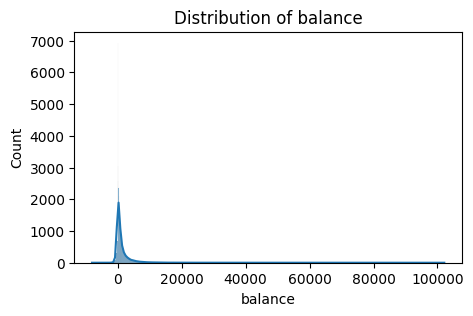

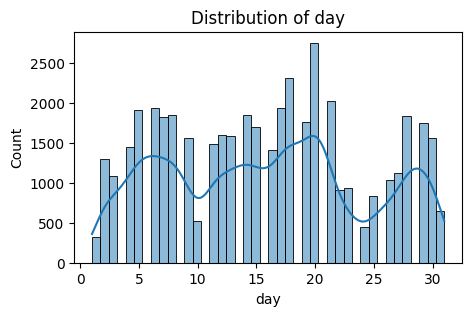

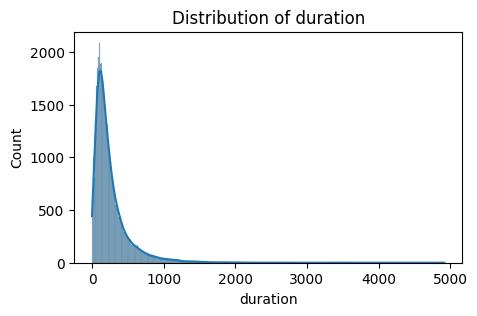

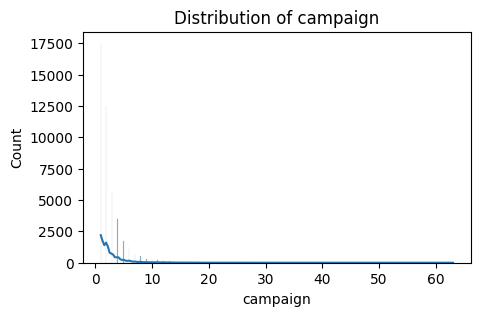

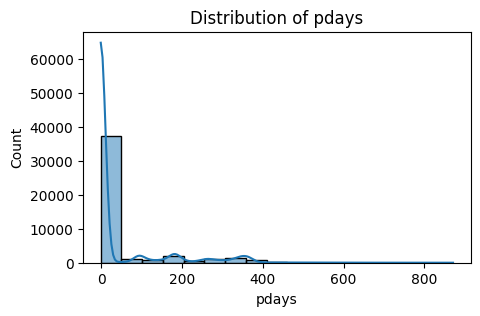

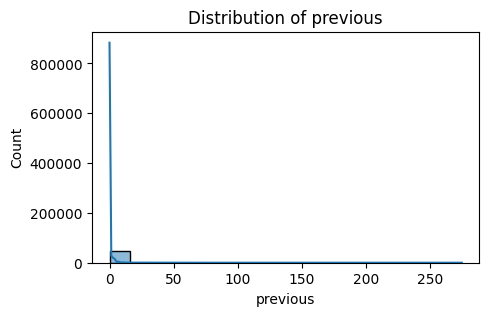

In [38]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**Features such as balance and duration appear skewed, which is common in banking and campaign-related datasets.**

### 5. Univariate EDA – Categorical Features.

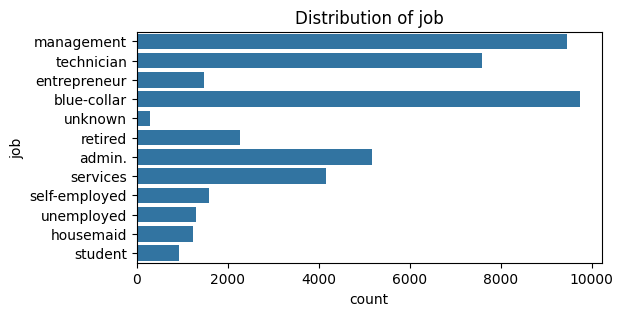

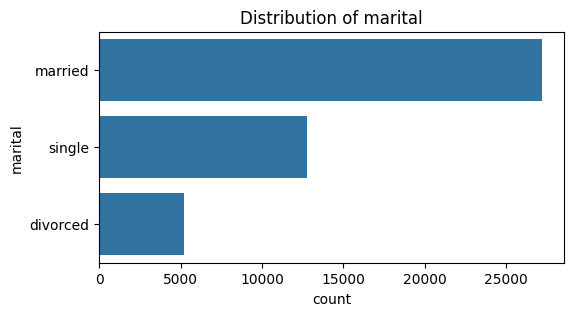

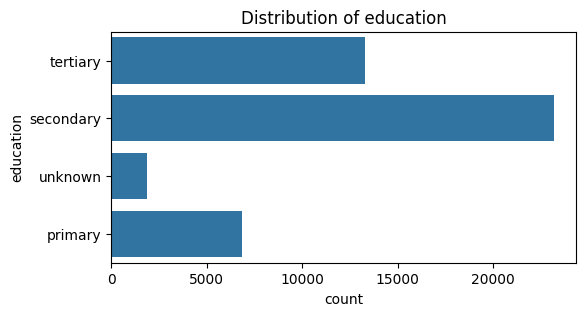

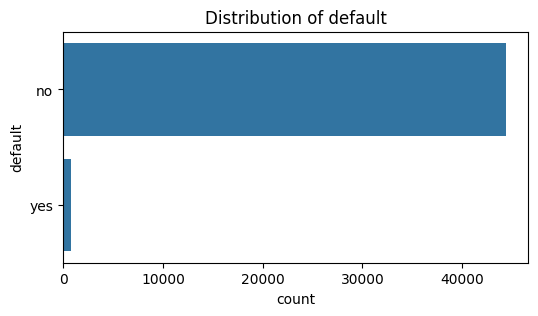

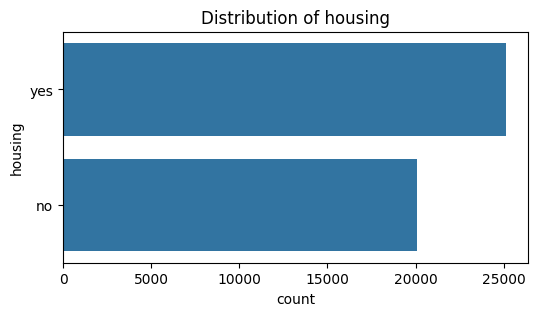

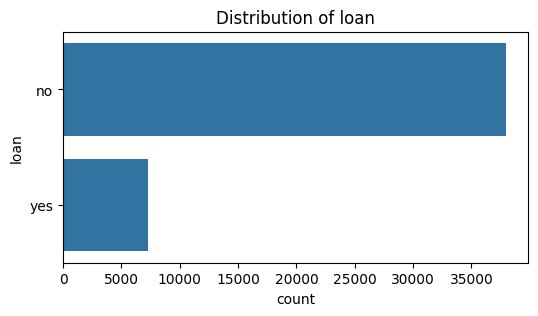

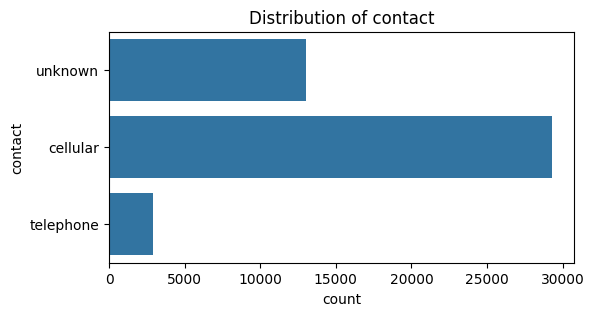

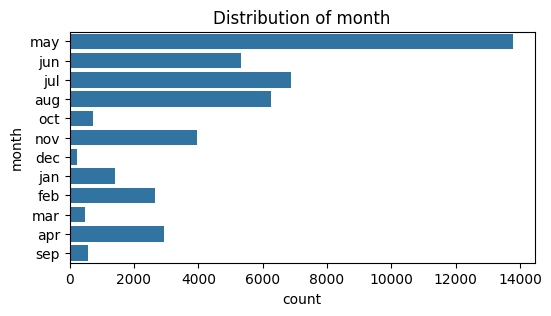

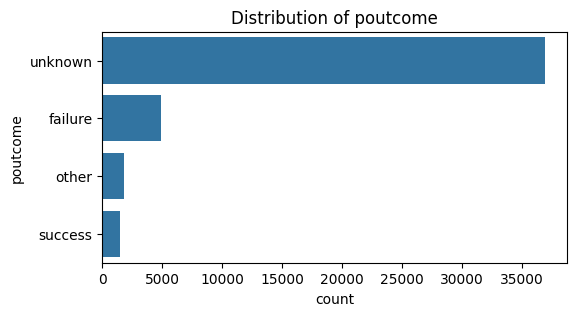

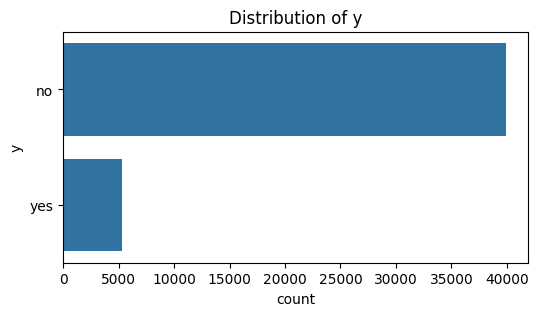

In [39]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

### Important Insight--
Several features contain "unknown" → implicit missing values

### 6. Bivariate EDA – Features vs Target

**Bivariate analysis was performed to explore relationships between predictor variables and the subscription outcome.**

### Numerical vs Target

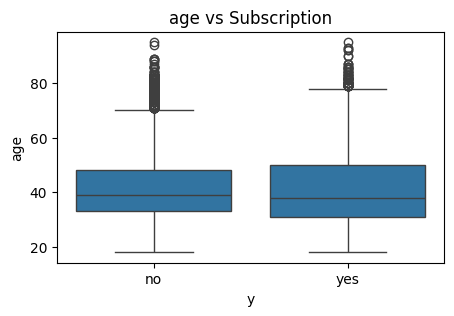

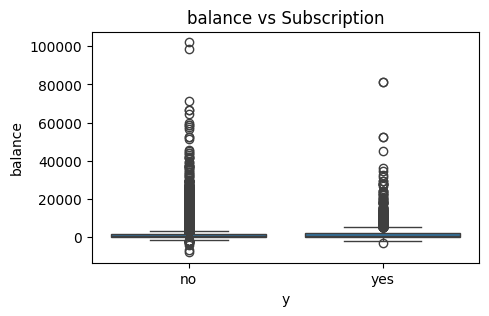

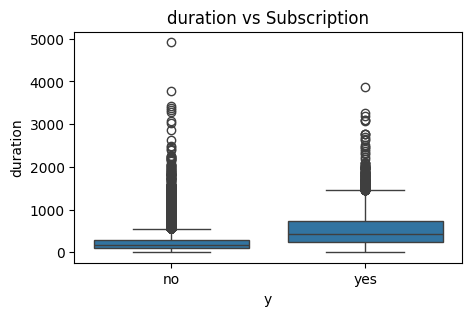

In [40]:
for col in ['age', 'balance', 'duration']:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs Subscription')
    plt.show()


### Categorical vs Target

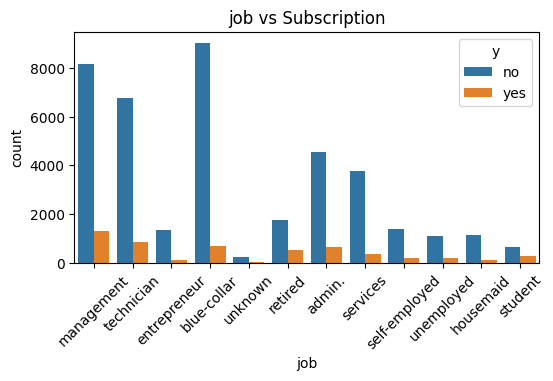

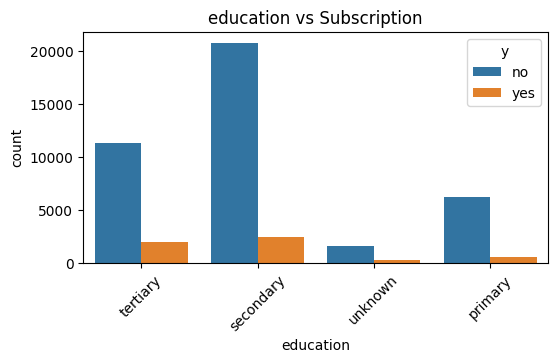

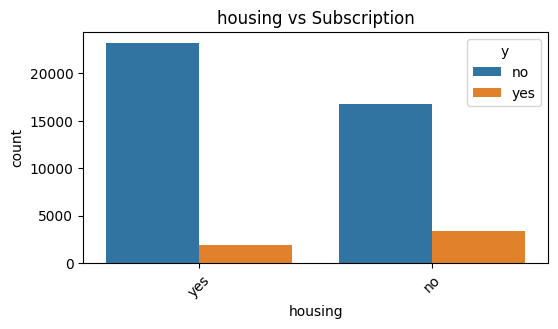

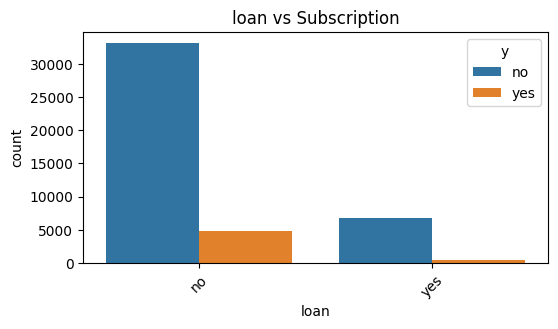

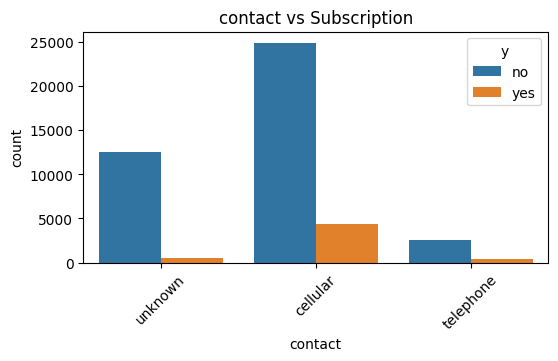

In [41]:
for col in ['job', 'education', 'housing', 'loan', 'contact']:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, hue='y', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Subscription')
    plt.show()


**Campaign-related variables appear to show stronger association with the target than some demographic variables, suggesting their likely predictive importance.**

### 7. Data Cleaning

In [42]:
# Handle Unknown Values.

df.replace('unknown', pd.NA, inplace=True)
df.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


**The value unknown was treated as implicit missing data. For this initial version of the project, categorical missing values were imputed using the mode as a simple and interpretable baseline strategy.**

In [43]:
# Impute categorical missing values (mode).

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### 8. Feature Engineering.

In [44]:
# Encode target variable.

df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [45]:
# Handle pdays special case.

df['pdays'] = df['pdays'].replace(999, -1)

**The target variable was converted into binary form for classification. In addition, the special placeholder value in pdays was replaced with a more meaningful representation to improve interpretability.**

### 9. Encoding Categorical Variables.

In [46]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.shape

(45211, 39)

In [47]:
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,False,True,False,False,False,False,False
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,False,True,False,False,False,False,False
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,False,True,False,False,False,False,False
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,False,True,False,False,False,False,False
4,33,1,5,198,1,-1,0,0,True,False,...,False,False,False,False,True,False,False,False,False,False


**One-hot encoding increased the feature space from 17 original variables to 38 model-ready features.**

### 10. Train-Test Split and Feature Scaling.

In [48]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

num_features = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

**The train-test split was performed before scaling to avoid data leakage. The scaler was fitted on the training set only and then applied to the test set.**

In [49]:
# Final Dataset Snapshot (before modelling).

print("Final feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", X.shape[1])

Final feature matrix shape: (45211, 38)
Target shape: (45211,)
Number of features: 38


In [50]:
# Final Class Balance Check (after preprocessing).

y.value_counts(normalize=True)

,proportion
y,
0,0.883015
1,0.116985


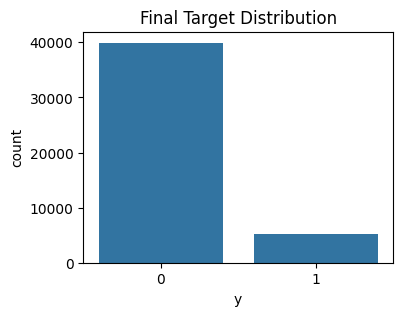

In [51]:
plt.figure(figsize=(4,3))
sns.countplot(x=y)
plt.title("Final Target Distribution")
plt.show()

### 11. Base Line Model.

Logistic Regression (Baseline)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.63      0.33      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043

ROC-AUC: 0.9006330395010493


Due to class imbalance, performance was evaluated using precision, recall, F1-score and ROC-AUC rather than accuracy alone.

### Decision Tree.

In [53]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      7985
           1       0.43      0.47      0.45      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.69      0.69      9043
weighted avg       0.87      0.87      0.87      9043

ROC-AUC: 0.692883277127601


### Random Forest (Stronger Model).

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.91      0.89      9043

ROC-AUC: 0.9195018897673213


**Baseline models were developed to compare the performance of different supervised classification approaches before further optimisation.**

### 12. Compare Models in a Clean Table

In [55]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred)
    ])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1", "ROC-AUC"])
results_df

,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression,0.899038,0.431153,0.650930
1,Decision Tree,0.865974,0.449091,0.692883
2,Random Forest,0.905452,0.491979,0.682440


**Model performance was assessed using precision, recall, F1-score, and ROC-AUC to reflect the imbalanced nature of the target variable.**

### 13. Handle Class Imbalance (Improvement Stage).

RandomForest with class_weight:

In [56]:
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')

In [57]:
rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:,1]

# Evaluate.
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_bal))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.68      0.33      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

ROC-AUC: 0.9206265765323213


**To address class imbalance, a cost-sensitive version of Random Forest was implemented using balanced class weights.**

In [58]:
# Comparision with original Random Forest Model.

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]

results = []

results.append(["Random Forest", *evaluate(rf, X_test, y_test)])
results.append(["Random Forest (Balanced)", *evaluate(rf_balanced, X_test, y_test)])

import pandas as pd
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.905452,0.662400,0.391304,0.491979,0.919502
1,Random Forest (Balanced),0.903793,0.682879,0.331758,0.446565,0.920627


“Applying class weighting improved minority class recall, which is important in subscription prediction.”

### Bar Plot Comparing F1 & ROC-AUC.

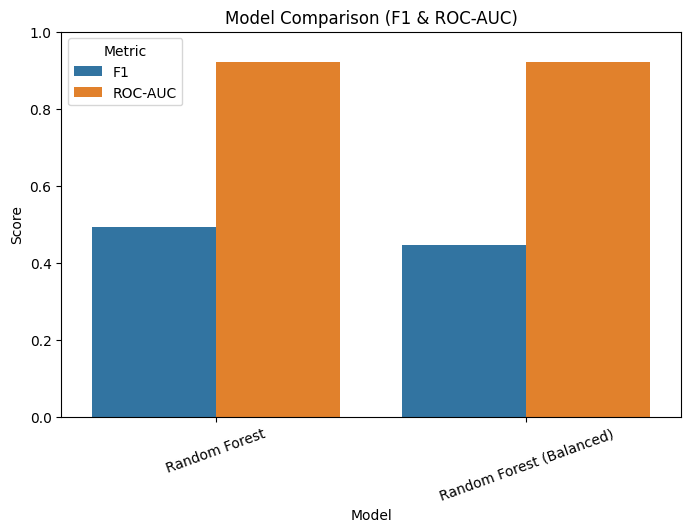

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8,5))

# Melt dataframe for plotting
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Comparison (F1 & ROC-AUC)")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

### Clean Comparison Plot (All Models, Key Metrics Only)

For imbalanced classification, the most important metrics are:
F1-score,
Recall,
ROC-AUC

So we’ll plot those.

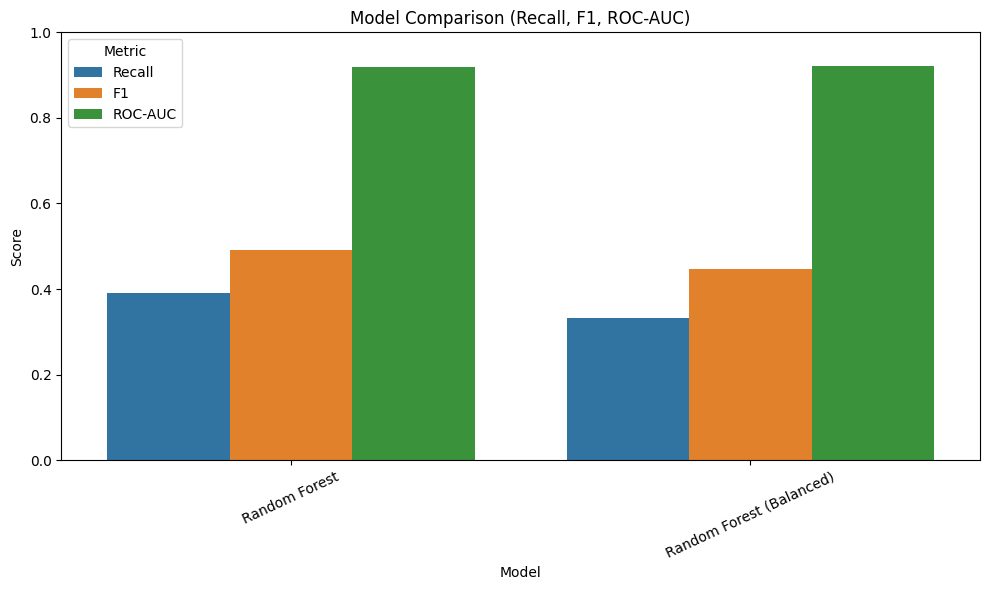

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

# Select important metrics only
metrics_to_plot = ["Recall", "F1", "ROC-AUC"]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Comparison (Recall, F1, ROC-AUC)")
plt.ylim(0,1)
plt.xticks(rotation=25)
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Final comparision of all models.

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = [
    ["Logistic Regression", accuracy_score(y_test, y_pred_log), precision_score(y_test, y_pred_log), recall_score(y_test, y_pred_log), f1_score(y_test, y_pred_log), roc_auc_score(y_test, y_prob_log)],
    ["Decision Tree", accuracy_score(y_test, y_pred_dt), precision_score(y_test, y_pred_dt), recall_score(y_test, y_pred_dt), f1_score(y_test, y_pred_dt), roc_auc_score(y_test, y_prob_dt)],
    ["Random Forest", accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf)],
    ["Random Forest (Balanced)", accuracy_score(y_test, y_pred_rf_bal), precision_score(y_test, y_pred_rf_bal), recall_score(y_test, y_pred_rf_bal), f1_score(y_test, y_pred_rf_bal), roc_auc_score(y_test, y_prob_rf_bal)]
]

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.899038,0.632541,0.327032,0.431153,0.900633
1,Decision Tree,0.865974,0.432574,0.466919,0.449091,0.692883
2,Random Forest,0.905452,0.662400,0.391304,0.491979,0.919502
3,Random Forest (Balanced),0.903793,0.682879,0.331758,0.446565,0.920627


### Confusion Matrix.

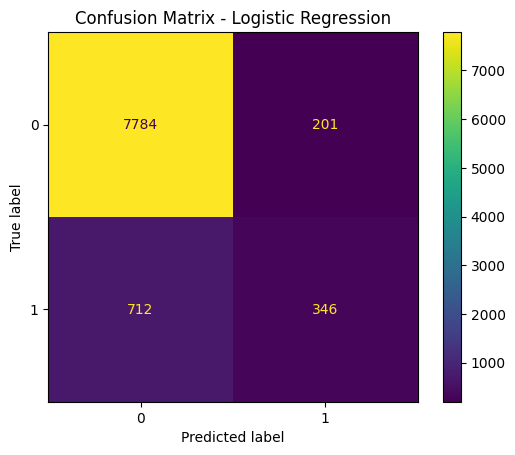

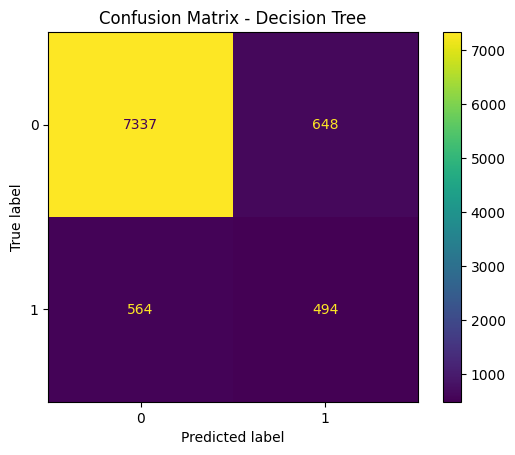

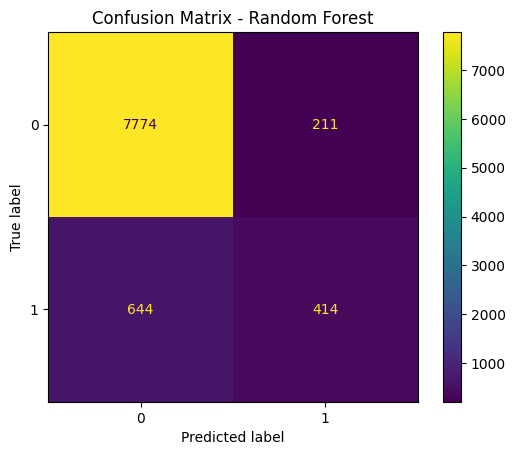

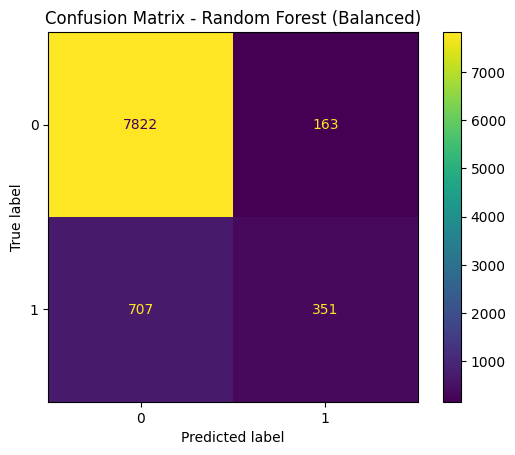

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Random Forest (Balanced)": rf_balanced
}

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### Cross Validation.

In [63]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_balanced,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

Cross-validation F1 scores: [0.41740532 0.3742591  0.4217356  0.40661157 0.43230016]
Mean CV F1: 0.41046235166893463


**Cross-validation was used to assess the stability of the selected model across multiple folds of the training data.**

### Hyper Parameter Tuning -- Grid SearchCV

In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


### Feature Importance.

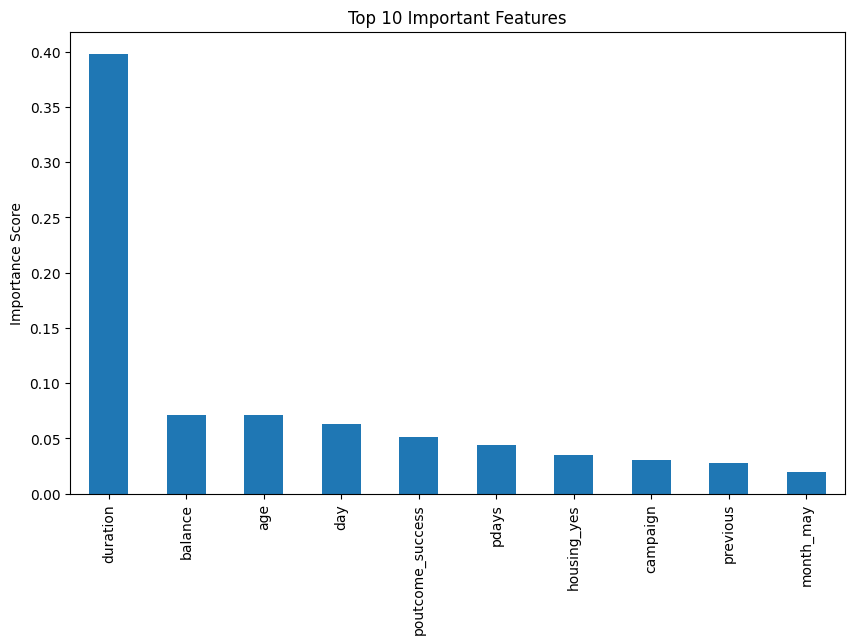

In [65]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

### Precision Recall curve.

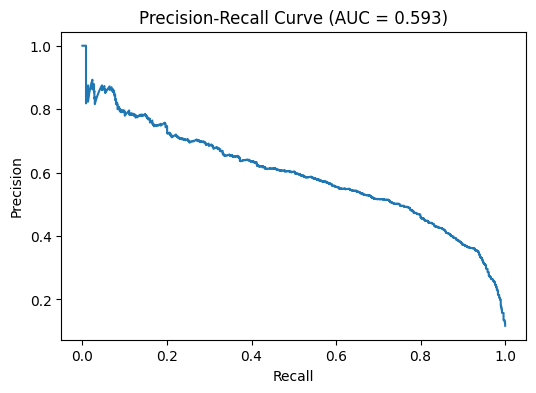

In [66]:
from sklearn.metrics import precision_recall_curve, auc

y_prob_best = best_rf.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_best)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
plt.show()

**Random Forest achieved the best balance between precision, recall, and overall discrimination ability, with the highest F1-score among the tested models. Although a class-weighted Random Forest was introduced to address class imbalance, it did not significantly improve minority-class detection compared with the standard Random Forest.**

## Final Conclusion

The project workflow included data loading, exploratory data analysis, preprocessing, feature encoding, scaling, baseline modelling, imbalance handling, model comparison, and model improvement. The final stages focused on validating and optimising the best-performing model, as well as interpreting its predictions using feature importance and imbalance-aware evaluation metrics.